In [1]:
# ============================================
# 0. Imports
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# 1. Load spectral summary
# ============================================
spectral = pd.read_csv("spectral_summary.csv")
spectral = spectral.rename(columns={
    "region": "target_region",
    "mean_lf_hf": "spectral_lf_hf",
    "mean_centroid": "spectral_centroid"
})

print("Loaded spectral summary:")
print(spectral.head())


Loaded spectral summary:
  target_region  spectral_centroid  spectral_lf_hf  n_images
0      hokkaido         135.191831        0.499616       100
1       jiuzhai         121.361369        0.786610       100
2    jiuzhai_02          89.375327        1.505914       100
3    jiuzhai_05         121.361369        0.786610       100
4        lombok         126.221242        0.643847       100


In [2]:
baseline = pd.read_csv("../../results/baseline/final_source_only_100_0.csv")
ll = pd.read_csv("../../results/new_wavelet/test/ll.csv")
hf = pd.read_csv("../../results/new_wavelet/test/hf.csv")

print("Loaded baseline, LL, HF files.")


# ============================================
# 3. Compute LL importance (IoU_LL - IoU_HF)
# ============================================
llhf = ll.merge(
    hf[["source_region", "target_region", "iou", "bf1"]],
    on=["source_region", "target_region"],
    suffixes=("_LL", "_HF")
)

llhf["LL_importance_iou"] = llhf["iou_LL"] - llhf["iou_HF"]
llhf["LL_importance_bf1"] = llhf["bf1_LL"] - llhf["bf1_HF"]

print("Computed LL importance.")

print(llhf.head())


Loaded baseline, LL, HF files.
Computed LL importance.
         source_region               target_region  precision  recall      f1  \
0  Hokkaido Iburi-Tobu   Jiuzhai valley (UAV-0.2m)     0.6565  0.5805  0.6162   
1  Hokkaido Iburi-Tobu   Jiuzhai valley (UAV-0.5m)     0.6328  0.6805  0.6558   
2  Hokkaido Iburi-Tobu                      Lombok     0.0990  0.6023  0.1700   
3  Hokkaido Iburi-Tobu          Longxi River (SAT)     0.9663  0.0344  0.0665   
4  Hokkaido Iburi-Tobu          Longxi River (UAV)     0.6086  0.2075  0.3095   

   iou_LL    miou      oa  bf1_LL  iou_HF  bf1_HF  LL_importance_iou  \
0  0.4453  0.6198  0.8235  0.1292  0.0697  0.0714             0.3756   
1  0.4879  0.6995  0.9181  0.3269  0.0374  0.1180             0.4505   
2  0.0929  0.4552  0.8208  0.2028  0.0000  0.0000             0.0929   
3  0.0344  0.4691  0.9042  0.0057  0.0000  0.0000             0.0344   
4  0.1831  0.5120  0.8464  0.1489  0.0000  0.0003             0.1831   

   LL_importance_bf1  
0 

In [24]:
w05r = pd.read_csv("../../results/new_wavelet/5_replace.csv")
w05r["alpha"] = 0.05
w05r["method"] = "replace"

w05m = pd.read_csv("../../results/new_wavelet/5_match.csv")
w05m["alpha"] = 0.05
w05m["method"] = "match"

w10r = pd.read_csv("../../results/new_wavelet/10_replace.csv")
w10r["alpha"] = 0.10
w10r["method"] = "replace"

w10m = pd.read_csv("../../results/new_wavelet/10_match.csv")
w10m["alpha"] = 0.10
w10m["method"] = "match"

wave = pd.concat([w05r, w05m, w10r, w10m], ignore_index=True)

print("Loaded 4 wavelet CSVs:")
print(wave.head())

Loaded 4 wavelet CSVs:
         source_region               target_region  precision  recall      f1  \
0  Hokkaido Iburi-Tobu   Jiuzhai valley (UAV-0.2m)     0.4934  0.6500  0.5610   
1  Hokkaido Iburi-Tobu   Jiuzhai valley (UAV-0.5m)     0.4446  0.7566  0.5601   
2  Hokkaido Iburi-Tobu                      Lombok     0.1374  0.5055  0.2161   
3  Hokkaido Iburi-Tobu          Longxi River (SAT)     0.2482  0.0003  0.0006   
4  Hokkaido Iburi-Tobu          Longxi River (UAV)     0.6185  0.0966  0.1671   

      iou    miou      oa     bf1  alpha   method  
0  0.3899  0.5474  0.7518  0.0918   0.05  replace  
1  0.3890  0.6199  0.8637  0.2125   0.05  replace  
2  0.1211  0.5038  0.8882  0.1756   0.05  replace  
3  0.0003  0.4506  0.9009  0.0000   0.05  replace  
4  0.0912  0.4644  0.8402  0.0771   0.05  replace  


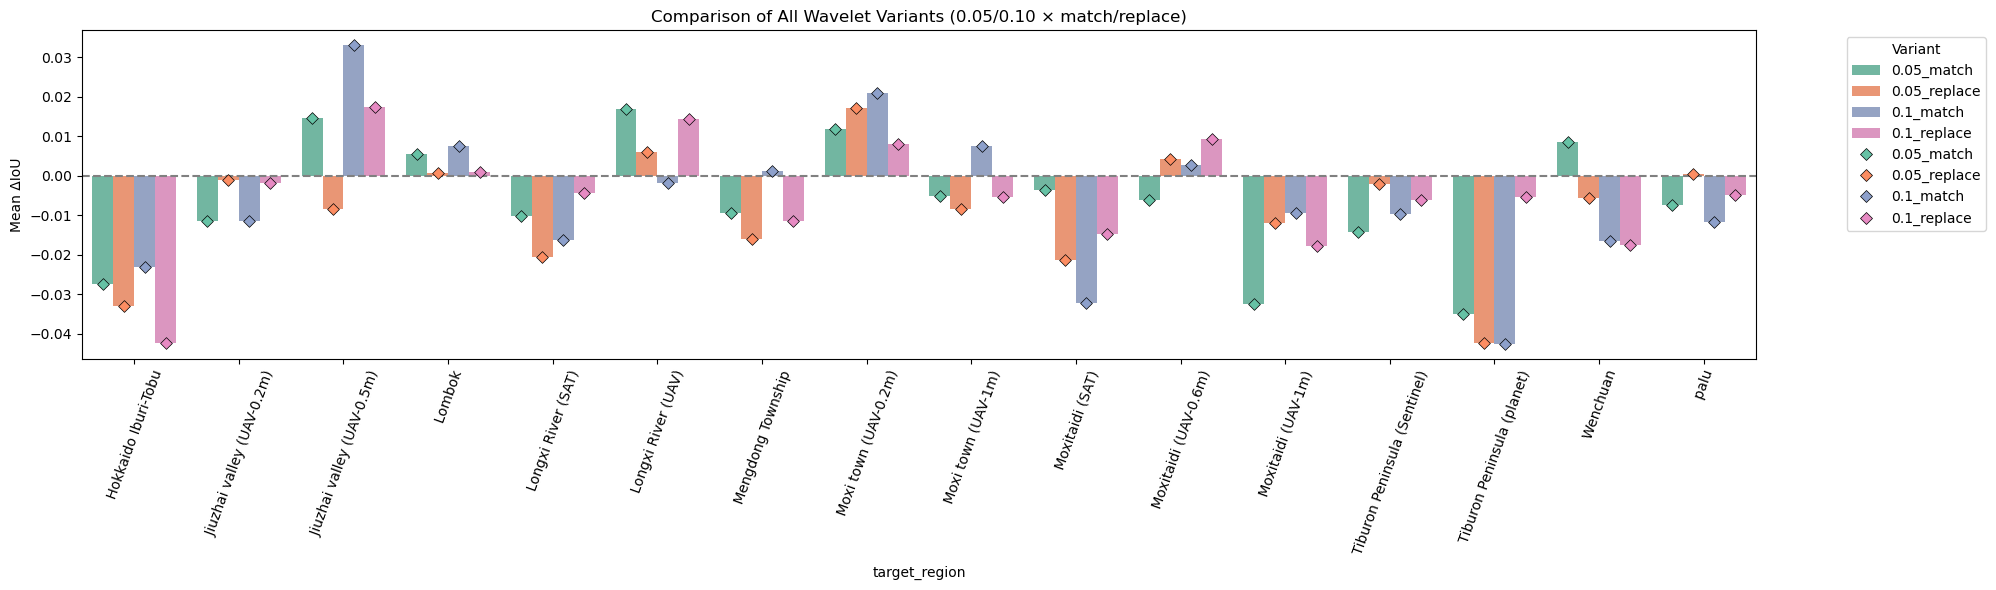

In [27]:

wave_merged = wave.merge(
    baseline[["source_region", "target_region", "iou"]],
    on=["source_region", "target_region"],
    suffixes=("", "_baseline")
)

wave_merged["delta_iou"] = wave_merged["iou"] - wave_merged["iou_baseline"]

wave_target = wave_merged.groupby(
    ["target_region", "alpha", "method"]
)["delta_iou"].mean().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt

# Create a combined label for each variant
wave_target["variant"] = wave_target.apply(
    lambda row: f"{row['alpha']}_{row['method']}", axis=1
)

plt.figure(figsize=(20,6))

# Barplot comparing all 4 variants
sns.barplot(
    data=wave_target,
    x="target_region",
    y="delta_iou",
    hue="variant",
    dodge=True,
    palette="Set2"
)

# Add dots for individual data points (optional)
sns.stripplot(
    data=wave_target,
    x="target_region",
    y="delta_iou",
    hue="variant",
    dodge=True,
    marker="D",
    size=6,
    palette="Set2",
    edgecolor="black",
    linewidth=0.5
)

plt.axhline(0, linestyle="--", color="gray")
plt.xticks(rotation=70)
plt.ylabel("Mean ΔIoU")
plt.title("Comparison of All Wavelet Variants (0.05/0.10 × match/replace)")
plt.legend(title="Variant", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




In [5]:
wave_merged = wave.merge(
    baseline[["source_region", "target_region", "iou", "bf1"]],
    on=["source_region", "target_region"],
    suffixes=("", "_baseline")
)

wave_merged["delta_iou"] = wave_merged["iou"] - wave_merged["iou_baseline"]
wave_merged["delta_bf1"] = wave_merged["bf1"] - wave_merged["bf1_baseline"]

print("Wavelet merged shape:", wave_merged.shape)

Wavelet merged shape: (960, 15)


In [6]:
wave_full = wave_merged.merge(
    llhf[["source_region", "target_region", "LL_importance_iou", "LL_importance_bf1"]],
    on=["source_region", "target_region"],
    how="left"
)

wave_full = wave_full.merge(
    spectral,
    on="target_region",
    how="left"
)

print("wave_full shape:", wave_full.shape)

wave_full shape: (960, 20)


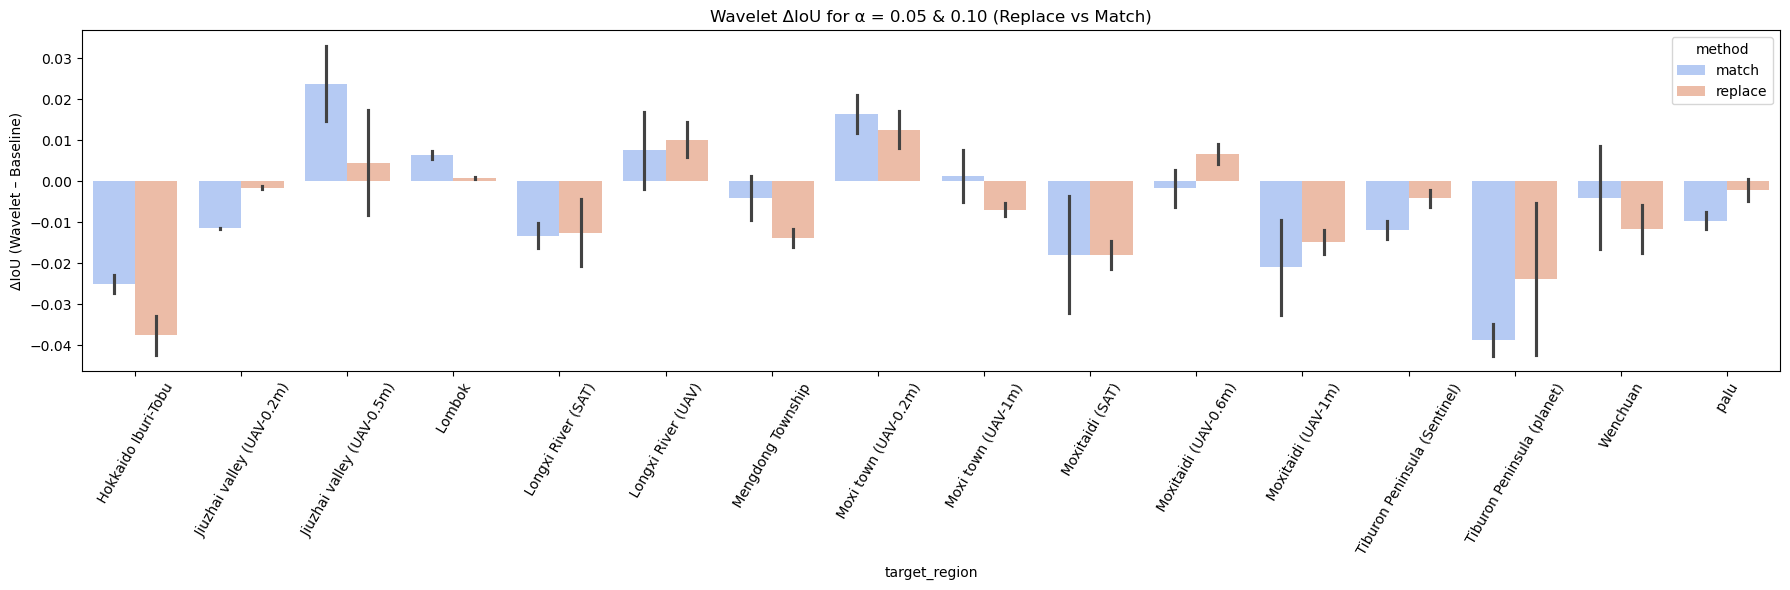

In [7]:
plt.figure(figsize=(18,6))
wave_agg = wave_full.groupby(["target_region", "alpha", "method"])["delta_iou"].mean().reset_index()

sns.barplot(
    data=wave_agg,
    x="target_region",
    y="delta_iou",
    hue="method",
    palette="coolwarm"
)

plt.xticks(rotation=60)
plt.ylabel("ΔIoU (Wavelet – Baseline)")
plt.title("Wavelet ΔIoU for α = 0.05 & 0.10 (Replace vs Match)")
plt.tight_layout()
plt.show()


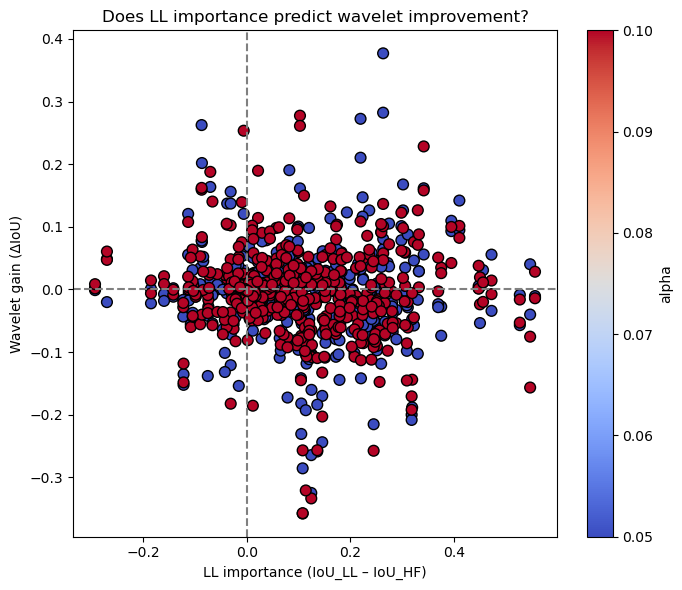

In [8]:
plt.figure(figsize=(7,6))
plt.scatter(
    wave_full["LL_importance_iou"],
    wave_full["delta_iou"],
    c=wave_full["alpha"],
    cmap="coolwarm",
    s=60,
    edgecolor="black"
)

plt.axhline(0, linestyle="--", color="gray")
plt.axvline(0, linestyle="--", color="gray")

plt.xlabel("LL importance (IoU_LL – IoU_HF)")
plt.ylabel("Wavelet gain (ΔIoU)")
plt.title("Does LL importance predict wavelet improvement?")
plt.colorbar(label="alpha")
plt.tight_layout()
plt.show()


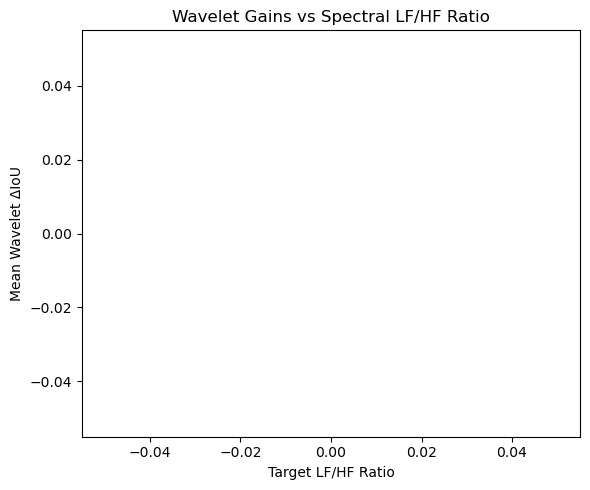

In [9]:
spec_plot = wave_full.groupby("target_region")["delta_iou"].mean().reset_index()
spec_plot = spec_plot.merge(
    spectral[["target_region", "spectral_lf_hf"]],
    on="target_region",
    how="left"
)

plt.figure(figsize=(6,5))
plt.scatter(
    spec_plot["spectral_lf_hf"],
    spec_plot["delta_iou"],
    s=60,
    edgecolor="black"
)

plt.xlabel("Target LF/HF Ratio")
plt.ylabel("Mean Wavelet ΔIoU")
plt.title("Wavelet Gains vs Spectral LF/HF Ratio")
plt.tight_layout()
plt.show()


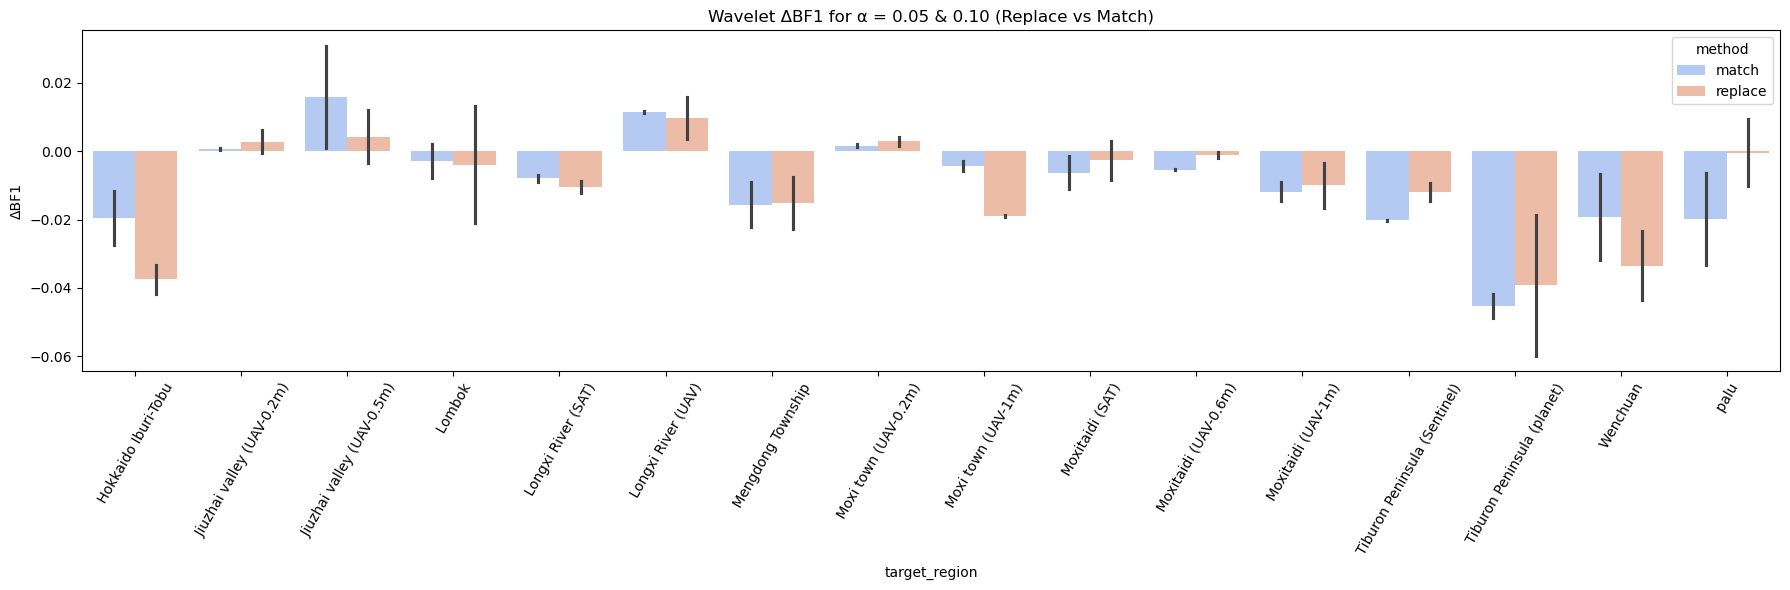

In [10]:
plt.figure(figsize=(18,6))
wave_bf1 = wave_full.groupby(["target_region", "alpha", "method"])["delta_bf1"].mean().reset_index()

sns.barplot(
    data=wave_bf1,
    x="target_region",
    y="delta_bf1",
    hue="method",
    palette="coolwarm"
)

plt.xticks(rotation=60)
plt.ylabel("ΔBF1")
plt.title("Wavelet ΔBF1 for α = 0.05 & 0.10 (Replace vs Match)")
plt.tight_layout()
plt.show()


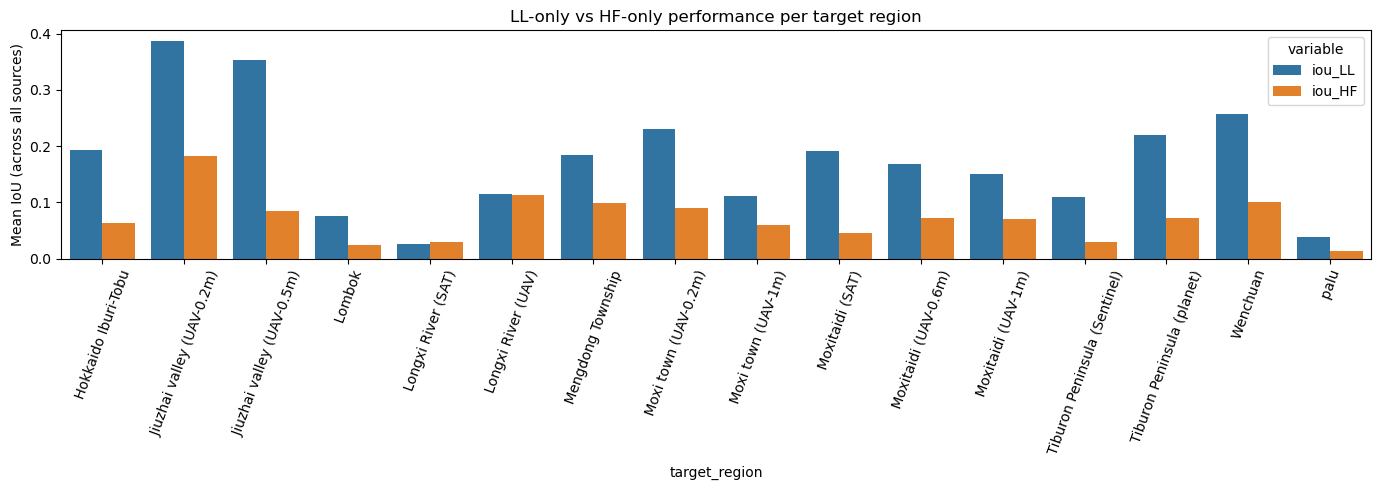

In [11]:
# LL vs HF importance per target (aggregated across all sources)
llhf_target = llhf.groupby("target_region")[
    ["iou_LL", "iou_HF", "LL_importance_iou"]
].mean().reset_index()

plt.figure(figsize=(14,5))
sns.barplot(
    data=llhf_target.melt(id_vars="target_region", 
                          value_vars=["iou_LL", "iou_HF"]),
    x="target_region",
    y="value",
    hue="variable"
)
plt.xticks(rotation=70)
plt.ylabel("Mean IoU (across all sources)")
plt.title("LL-only vs HF-only performance per target region")
plt.tight_layout()
plt.show()


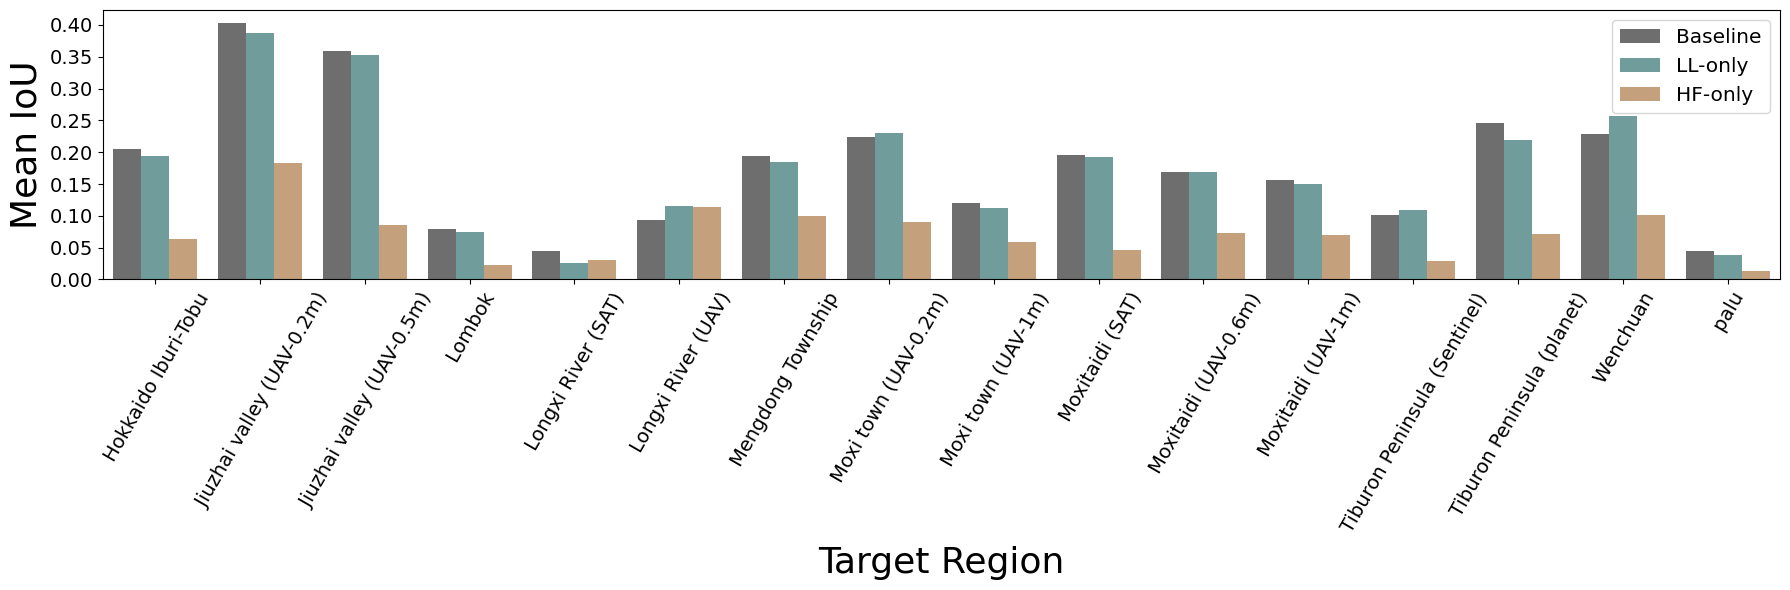

In [7]:
baseline_tgt = baseline.groupby("target_region")["iou"].mean().reset_index()
baseline_tgt = baseline_tgt.rename(columns={"iou": "baseline_iou"})

ll_tgt = ll.groupby("target_region")["iou"].mean().reset_index()
ll_tgt = ll_tgt.rename(columns={"iou": "ll_iou"})

hf_tgt = hf.groupby("target_region")["iou"].mean().reset_index()
hf_tgt = hf_tgt.rename(columns={"iou": "hf_iou"})

# --- Merge them ---
df = baseline_tgt.merge(ll_tgt, on="target_region").merge(hf_tgt, on="target_region")

# --- Melt for plotting ---
df_melt = df.melt(id_vars="target_region", 
                  value_vars=["baseline_iou", "ll_iou", "hf_iou"],
                  var_name="method",
                  value_name="iou")

# Clean labels
df_melt["method"] = df_melt["method"].map({
    "baseline_iou": "Baseline",
    "ll_iou": "LL-only",
    "hf_iou": "HF-only"
})

# --- Plot ---
plt.figure(figsize=(18,6))
sns.barplot(
    data=df_melt,
    x="target_region",
    y="iou",
    hue="method",
    palette = ["#6E6E6E", "#6AA3A3", "#D0A070"]

)

plt.xticks(rotation=60, fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel("Mean IoU", fontsize=26)
plt.xlabel("Target Region", fontsize=26)
# plt.title("Baseline vs LL-only vs HF-only (Per Target Region, No Adaptation)")
plt.legend(title="", fontsize=14.5)
plt.tight_layout()
plt.show()


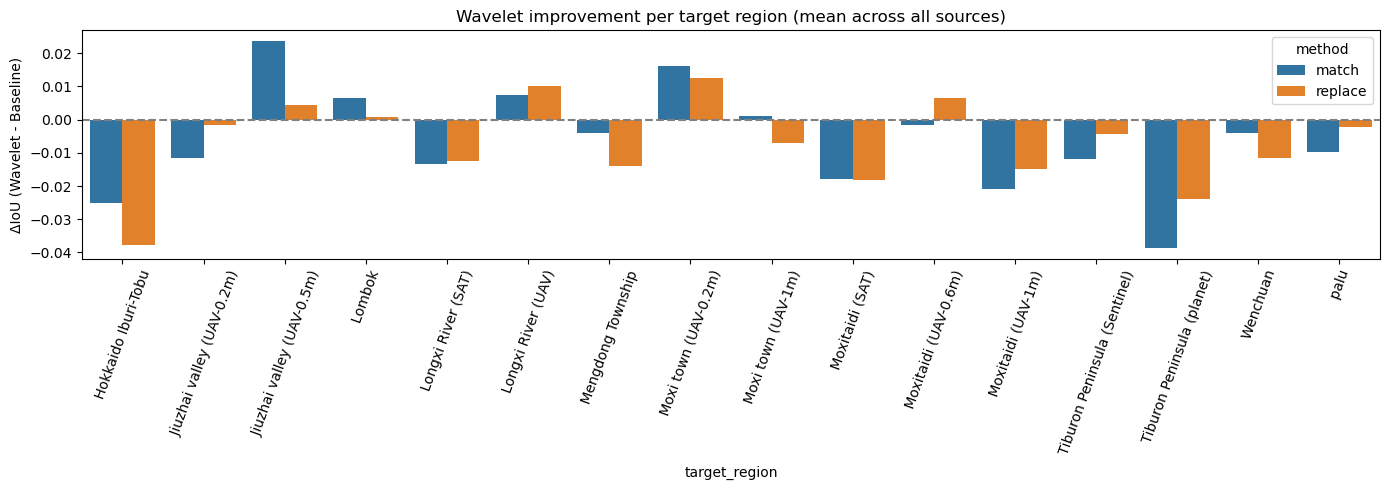

In [12]:
# Average wavelet improvement per target region
wave_target = wave_merged.groupby(["target_region", "method"])["delta_iou"].mean().reset_index()

plt.figure(figsize=(14,5))
sns.barplot(
    data=wave_target,
    x="target_region",
    y="delta_iou",
    hue="method"
)
plt.axhline(0, linestyle="--", color="gray")
plt.xticks(rotation=70)
plt.ylabel("ΔIoU (Wavelet - Baseline)")
plt.title("Wavelet improvement per target region (mean across all sources)")
plt.tight_layout()
plt.show()


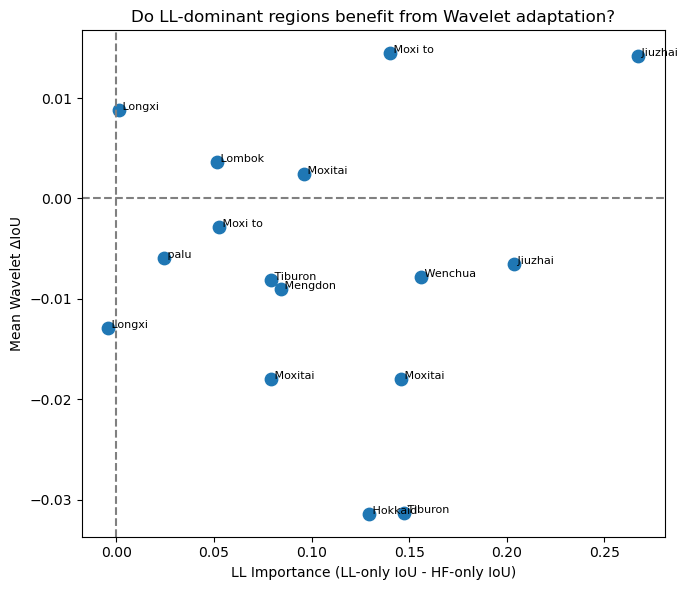

In [13]:
# LL importance (average) per target
ll_imp = llhf_target[["target_region", "LL_importance_iou"]]

# Mean wavelet gain per target
wave_gain = wave_merged.groupby("target_region")["delta_iou"].mean().reset_index()

# Merge
diag_df = ll_imp.merge(wave_gain, on="target_region")

plt.figure(figsize=(7,6))
plt.scatter(diag_df["LL_importance_iou"], diag_df["delta_iou"], s=80)
plt.axhline(0, linestyle="--", color="gray")
plt.axvline(0, linestyle="--", color="gray")

plt.xlabel("LL Importance (LL-only IoU - HF-only IoU)")
plt.ylabel("Mean Wavelet ΔIoU")
plt.title("Do LL-dominant regions benefit from Wavelet adaptation?")
for i, row in diag_df.iterrows():
    plt.annotate(row["target_region"][:8], 
                 (row["LL_importance_iou"], row["delta_iou"]), fontsize=8)

plt.tight_layout()
plt.show()


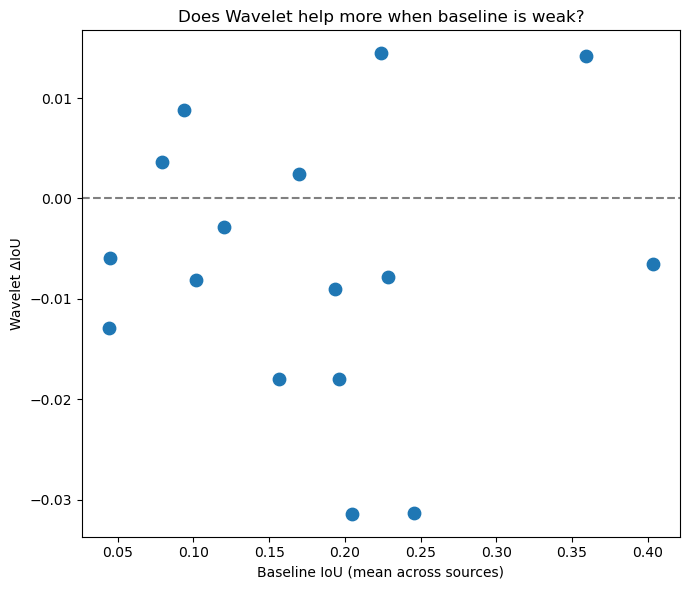

In [14]:
baseline_target = baseline.groupby("target_region")["iou"].mean().reset_index()

df = baseline_target.merge(wave_gain, on="target_region")

plt.figure(figsize=(7,6))
plt.scatter(df["iou"], df["delta_iou"], s=80)
plt.axhline(0, linestyle="--", color="gray")
plt.xlabel("Baseline IoU (mean across sources)")
plt.ylabel("Wavelet ΔIoU")
plt.title("Does Wavelet help more when baseline is weak?")
plt.tight_layout()
plt.show()
